## Goal: get dsa <-> PF muon cross references working

The goal is to edit the schema to be able to access the DSA muons matched to PF muons (and vice versa). 

Running on Coffea2025.5.rc build (release candidate).

Accomplished:
1. Using NanoEventsFactory, test the custom NanoAOD schema to add the cross references between DSA and PF muons and add a "matched_muons" collection to access the muons that correspond to DSAMuon_muonMatchNidx branches
2. Create a stripped-down version of the schema, that only adds what we need on top of the standard NanoAODSchema
3. Update the processor so that the fields are handled correctly when building up the lepton jets (done, with the exception of the nested matched indices are not included in the lj constituent dsa muons)
4. Add a new selection method that works as expected when applying masks. Make sure the global indices do not reach across events after applying selections to the target collection (to get this to work for real)
5. Figure out how to attach the info in the muonMatchN branches to correspond to the muons in matched_muons (so we can check the number of matched segments for muons passing our selections)



Remaining steps:
1. Repeat some of the above but for dsa muons matched to PF
2. (Postponed) Then attach the info for the CSC and DT matches, which will be more difficult.
3. (Postponed) Figure out how to change the type of the LLPNanoAOD idx branches from float to int32 (to avoid having to modify coffea). See note.
Nevermind: new step is to make our own coffea fork that comments out the offending lines, and use that instead.

*NOTE:* Right now, the code only works if you comment out [these lines](https://github.com/scikit-hep/coffea/blob/539c4b58961b7bae86038caf67f1c7db83dded3a/coffea/nanoevents/transforms.py#L129-L130) in your local coffea install. It would be better to change the type of the muonMatchNidx branches to int32 (it's currently a float for some reason), but I haven't figured out how. 


# Test with NanoEventsFactory

In [1]:
# python
# python
import awkward as ak
import numpy as np
import sys
import os
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
#from sidm.tools import llpnanoaodschema, 
from sidm.tools import utilities
#from sidm.tools import full_nano
from sidm.tools import llpschema
# always reload local modules to pick up changes during development
importlib.reload(llpschema)
importlib.reload(utilities)

/tmp/ipykernel_2463/3065739926.py:9: DeprecationWarning: NanoEventsFactory.from_root() behavior has changed.
    The default behavior is that now it reads the input root file using
    the newly developed virtual arrays backend of awkward instead of dask.
    The backend choice is controlled by the `mode` argument of the method
    which can be set to "eager", "virtual", or "dask".
    The new default is "virtual" while the `delayed` argument has been removed.
    The old `delayed=True` is now equivalent to `mode="dask"`.
    The old `delayed=False` is now equivalent to `mode="eager"`.
    
  from coffea.nanoevents import NanoEventsFactory, NanoAODSchema


<module 'sidm.tools.utilities' from '/home/cms-jovyan/SIDM_forks_2025/dsaMatching/SIDM/sidm/tools/utilities.py'>

In [2]:
samples = [
    '2Mu2E_500GeV_5p0GeV_8p0mm',
]
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml")
# create events collection from single file
fname = fileset[samples[0]]["files"][0]

In [3]:
import uproot
treepath="Events"
branch_names = ["DSAMuon_muonMatch1idx","Jet_muonIdx1","Muon_mass"]
with uproot.open(f"{fname}:{treepath}") as tree:
    for branch_name in branch_names:
        branch = tree[branch_name]
        # The 'form' describes the structure and primitive type
        print(f"\n--- Inspecting branch: '{branch_name}' in '{fname}:{treepath}' ---")
        print(f"Branch interpretation (form): {branch.interpretation}")




--- Inspecting branch: 'DSAMuon_muonMatch1idx' in 'root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-500_MDp-5p0_ctau-8p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-500_MDp-5p0_ctau-8p0_v3_part-0.root:Events' ---
Branch interpretation (form): AsJagged(AsDtype('>f4'))

--- Inspecting branch: 'Jet_muonIdx1' in 'root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-500_MDp-5p0_ctau-8p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-500_MDp-5p0_ctau-8p0_v3_part-0.root:Events' ---
Branch interpretation (form): AsJagged(AsDtype('>i4'))

--- Inspecting branch: 'Muon_mass' in 'root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-500_MDp-5p0_ctau-8p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-500_MDp-5p0_ctau-8p0_v3_part-0.root:Events' ---
Branch interpretation (form): As

In [4]:
factory_llp = NanoEventsFactory.from_root(
    {fname: "Events"},
    schemaclass=llpschema.LLPNanoAODSchema
    #schemaclass=full_nano.NanoAODSchema
    #schemaclass=NanoAODSchema
    #schemaclass=llpnanoaodschema.LLPNanoAODSchema,
)

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


In [5]:
type(factory_llp)

coffea.nanoevents.factory.NanoEventsFactory

In [6]:
events_llp = factory_llp.events()

In [7]:
pf = events_llp.Muon
dsa = events_llp.DSAMuon
jet = events_llp.Jet
#Check if matched_muons is included in the DSAMuon collection
all_attrs = dir(dsa)
print([attr for attr in all_attrs if attr.startswith('mat')])

#print(dsa)
#dsa.fields

['matched_muons']


The following command (specifically materializing the dsa.muonIdxG array) will only work if you comment out [these lines](https://github.com/scikit-hep/coffea/blob/539c4b58961b7bae86038caf67f1c7db83dded3a/coffea/nanoevents/transforms.py#L129-L130) in your local coffea install (you might have to add it on each coffea casa node). It would be better to change the type of the `muonMatchNidx` branches to `int32` (it's currently a float for some reason), but I haven't figured out how.

Locally, edit the file at  /usr/local/lib/python3.12/site-packages/coffea/nanoevents/transforms.py

In [8]:
ak.materialize(dsa.muonMatch1)
ak.materialize(dsa.muonMatch1idx)
ak.materialize(dsa.pt)
ak.materialize(pf.pt)
ak.materialize(dsa.muonMatch4idx)
ak.materialize(dsa.muonIdxG)
ak.materialize(dsa.muonMatch1idxG)


<Array [[4607182418800017408, 0], ..., [...]] type='4364 * var * int64[para...'>

In event 1, we have three dsa muons and 2 pf muons. The first dsa muon matches the 2nd pf muon and vice versa:

In [9]:
print("DSA pt in events 0-2:", dsa.pt[0:3].to_list())
print("PF pt in events 0-2:", pf[0:3].pt.to_list())
#print(dsa.muonMatch1idxG[1]) #don't want to use this directly; numbers aren't easily interpretable
print("ID of PF muons matched to DSA muons in events 0-2:",dsa.muonIdxG[0:3].to_list()) #global index (for the first 5 matches)
print("pt of PF muons matched to DSA muons in event 1:",dsa.matched_muons.pt[1].to_list())

DSA pt in events 0-2: [[90.20301055908203, 169.33285522460938], [5.917826175689697, 321.9776916503906, 1.6178698539733887], [161.76913452148438, 24.506929397583008]]
PF pt in events 0-2: [[717.1842651367188, 135.23300170898438], [212.15811157226562, 5.346219539642334], [197.0467071533203, 21.183835983276367]]
ID of PF muons matched to DSA muons in events 0-2: [[[1, 0, -1, -1, -1], [0, 1, -1, -1, -1]], [[3, 2, -1, -1, -1], [2, 3, -1, -1, -1], [3, 2, -1, -1, -1]], [[4, 5, -1, -1, -1], [5, 4, -1, -1, -1]]]
pt of PF muons matched to DSA muons in event 1: [[5.346219539642334, 212.15811157226562, None, None, None], [212.15811157226562, 5.346219539642334, None, None, None], [5.346219539642334, 212.15811157226562, None, None, None]]


Great, it appears matched_muons allows me to access the muons that correspond to `muonMatchNidx` branches. Next I'll check what happens after applying a selection to the muons

In [10]:
all_attrs_matched = dir(dsa.matched_muons)
print([attr for attr in all_attrs_matched if attr.startswith('num')])
print("number of segment matches for PF muons matched to DSA muons in event 0:",dsa.matched_muons.numMatch[1].to_list())

['numMatch', 'numba_type']
number of segment matches for PF muons matched to DSA muons in event 0: [[4.0, 0.0, None, None, None], [3.0, 0.0, None, None, None], [0.0, 0.0, None, None, None]]


# Try to add info about the number of matches

We want the following variables to be attached to the matched_muon object

In [11]:
all_attrs = dir(dsa)
print([attr for attr in all_attrs if attr.startswith('muon')])

['muonCSCMatch1', 'muonCSCMatch1idx', 'muonCSCMatch2', 'muonCSCMatch2idx', 'muonCSCMatch3', 'muonCSCMatch3idx', 'muonDTMatch1', 'muonDTMatch1idx', 'muonDTMatch2', 'muonDTMatch2idx', 'muonDTMatch3', 'muonDTMatch3idx', 'muonIdxG', 'muonMatch1', 'muonMatch1idx', 'muonMatch1idxG', 'muonMatch2', 'muonMatch2idx', 'muonMatch2idxG', 'muonMatch3', 'muonMatch3idx', 'muonMatch3idxG', 'muonMatch4', 'muonMatch4idx', 'muonMatch4idxG', 'muonMatch5', 'muonMatch5idx', 'muonMatch5idxG']


First we need to assemble the number of matches into the right shape

In [12]:
dsa_matches = dsa.matched_muons
#Doesn't work: doesn't nest/broadcast/zip the arrays appropriately
#total =  ak.Array([dsa.muonMatch1, dsa.muonMatch2, dsa.muonMatch3, dsa.muonMatch4, dsa.muonMatch5])
#print(total) 
print("There are 2 dsa muons in the first event and 3 dsa muons in the second event.")
print(dsa.muonMatch1[0:2,:].to_list())
print(dsa.muonMatch2[0:2,:].to_list())
print(dsa.muonMatch3[0:2,:].to_list())
print(dsa.muonMatch4[0:2,:].to_list())
print(dsa.muonMatch5[0:2,:].to_list())


muon_match_total = ak.concatenate([
            dsa.muonMatch1[:, :, np.newaxis],
            dsa.muonMatch2[:, :, np.newaxis],
            dsa.muonMatch3[:, :, np.newaxis],
            dsa.muonMatch4[:, :, np.newaxis],
            dsa.muonMatch5[:, :, np.newaxis],
        ], axis=2) # Result: (events, dsa_muons, 5)

print()

print(muon_match_total[0:2,:,:].to_list())

print("Check that muon_match_total has the right nested structure")

print(muon_match_total)



There are 2 dsa muons in the first event and 3 dsa muons in the second event.
[[2.0, 3.0], [4.0, 3.0, 0.0]]
[[0.0, 0.0], [0.0, 0.0, 0.0]]
[[-1.0, -1.0], [-1.0, -1.0, -1.0]]
[[-1.0, -1.0], [-1.0, -1.0, -1.0]]
[[-1.0, -1.0], [-1.0, -1.0, -1.0]]

[[[2.0, 0.0, -1.0, -1.0, -1.0], [3.0, 0.0, -1.0, -1.0, -1.0]], [[4.0, 0.0, -1.0, -1.0, -1.0], [3.0, 0.0, -1.0, -1.0, -1.0], [0.0, 0.0, -1.0, -1.0, -1.0]]]
Check that muon_match_total has the right nested structure
[[[2, 0, -1, -1, -1], [3, 0, -1, -1, -1]], ..., [[0, 0, -1, -1, -1], ...]]


Now check the other match variables

Oh no... the CSC and DT matches have *their own* indices which don't necessarily match the general match indices.

Yet another complication is that Match4 and Match5 don't seem to exist for CSC or DT, even though they are listed in the documentation?

In [13]:
print("There are 2 dsa muons in the first event and 3 dsa muons in the second event.")
print(dsa.muonMatch1idx[0:2,:].to_list())
print(dsa.muonMatch2idx[0:2,:].to_list())
print(dsa.muonMatch3idx[0:2,:].to_list())
print(dsa.muonMatch4idx[0:2,:].to_list())
print(dsa.muonMatch5idx[0:2,:].to_list())

print()

print(dsa.muonCSCMatch1idx[0:2,:].to_list())
print(dsa.muonCSCMatch2idx[0:2,:].to_list())
print(dsa.muonCSCMatch3idx[0:2,:].to_list())
#print(dsa.muonCSCMatch4idx[0:2,:].to_list())
#print(dsa.muonCSCMatch5idx[0:2,:].to_list())

print()

print(dsa.muonCSCMatch1idx[0:2,:].to_list())
print(dsa.muonCSCMatch2idx[0:2,:].to_list())
print(dsa.muonCSCMatch3idx[0:2,:].to_list())
#print(dsa.muonCSCMatch4idx[0:2,:].to_list())
#print(dsa.muonCSCMatch5idx[0:2,:].to_list())


There are 2 dsa muons in the first event and 3 dsa muons in the second event.
[[1.0, 0.0], [1.0, 0.0, 1.0]]
[[0.0, 1.0], [0.0, 1.0, 0.0]]
[[-1.0, -1.0], [-1.0, -1.0, -1.0]]
[[-1.0, -1.0], [-1.0, -1.0, -1.0]]
[[-1.0, -1.0], [-1.0, -1.0, -1.0]]

[[1.0, 1.0], [1.0, 0.0, 1.0]]
[[0.0, 0.0], [0.0, 1.0, 0.0]]
[[-1.0, -1.0], [-1.0, -1.0, -1.0]]

[[1.0, 1.0], [1.0, 0.0, 1.0]]
[[0.0, 0.0], [0.0, 1.0, 0.0]]
[[-1.0, -1.0], [-1.0, -1.0, -1.0]]


Okay, focus on the main match variables for now. Can come back to the CSC and DT matches.

So next, we want to add muon_match_total to the dsa.matched_muons, so that I can do eg dsa.matched_muons.numMatch (try it here before adding it to the schema)

In [14]:
print(dsa_matches[0:2,:,:].pt.to_list())
print(muon_match_total[0:2,:,:].to_list())

concat = ak.with_field(dsa_matches, muon_match_total, where="numMatch")

new_attrs = dir(concat)
print([attr for attr in new_attrs if attr.startswith('n')])

print(concat["numMatch"][0:2,:,:].to_list())


[[[135.23300170898438, 717.1842651367188, None, None, None], [717.1842651367188, 135.23300170898438, None, None, None]], [[5.346219539642334, 212.15811157226562, None, None, None], [212.15811157226562, 5.346219539642334, None, None, None], [5.346219539642334, 212.15811157226562, None, None, None]]]
[[[2.0, 0.0, -1.0, -1.0, -1.0], [3.0, 0.0, -1.0, -1.0, -1.0]], [[4.0, 0.0, -1.0, -1.0, -1.0], [3.0, 0.0, -1.0, -1.0, -1.0], [0.0, 0.0, -1.0, -1.0, -1.0]]]
['nStations', 'nTrackerLayers', 'named_axis', 'nbytes', 'ndim', 'nearest', 'neg2D', 'neg3D', 'neg4D', 'negative', 'normChi2', 'not_equal', 'numMatch', 'numba_type']
[[[2.0, 0.0, None, None, None], [3.0, 0.0, None, None, None]], [[4.0, 0.0, None, None, None], [3.0, 0.0, None, None, None], [0.0, 0.0, None, None, None]]]


# New test: run in processor

Status: testing the new behavior

Note that we won't be able to access the matched_muons array if accessing a dsa muon from within a lepton jet (at least not for now)

In [15]:
# python
import sys, os
import importlib
# columnar analysis
from coffea.nanoevents import NanoAODSchema
from coffea import processor
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities
#from sidm.tools import full_nano
from sidm.tools import llpschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()

In [16]:
samples = [
    '2Mu2E_500GeV_5p0GeV_8p0mm',
]
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml")

In [17]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    schema=llpschema.LLPNanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    maxchunks=1,
    skipbadfiles=True,
)

channels = [
    "keep_all_events",
    "muon_only"
]
p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=True,
)

output = runner.run(fileset, treename='Events', processor_instance=p)
out = output["out"]

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:292: RuntimeWarning: invalid value 
encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))

...

Applying photons looseID

Applying cuts to the nested muons collection

['jetIdx', 'vy', 'muonCSCMatch2idx', 'dsaMatch1idx', 'r9', 'fsrPhotonIdxG', 'lostHits', 'highPurity', 
'mediumPromptId', 'dsaMatch3idx', 'genPartIdxG', 'vx', 'nStations', 'dEscaleUp', 'miniIsoId', 'softMva', 
'energyErr', 'softId', 'mvaFall17V2noIso', 'softMvaId', 'isGlobal', 'mvaLowPtId', 'dsaMatch4', 'mediumId', 
'dEscaleDown', 'ip3DBSSignedErr', 'trkNumTrkLayers', 'nCSCSegments', 'scEtOverPt', 'mvaFall17V2noIso_WP90', 
'dEsigmaUp', 'dsaMatch1', 'highPtId', 'dsaMatch2idxG', 'muonMatch5idx', 'muonDTMatch2idx', 'dsaMatch2idx', 
'isPFcand', 'normChi2', 'dxyPVTraj', 'outerPhi', 'tightCharge', 'mass', 'pfRelIso03_chg', 'muonDTMatch3', 
'triggerIdLoose', 'ptErr', 'isTracker', 'mvaId', 'muonMatch2idxG', 'mvaFall17V2noIso_WPL', 'dEsigmaDown', 
'dsaMatch1idxG', 'dsaMatch5', 'muonMatch3idx', 'trkNumDTHits', 'jetPtRelv2', 'dxyPVTrajErr', 'muonMatch4', 
'innerPhi', 'eInvMinusPInv', 'muonMatch4idxG', 'segmentComp', 'isStandalone', 'convVeto', 'trkNumCSCHits', 'dz', 
'dzBSErr', 'muonMatch2', 'deltaEtaSC', 'electronIdxG', 'photonIdxG', 'fsrPhotonIdx', 'dzPV', 'tightId', 
'cutBased_Fall17V1Bitmap', 'genPartIdx', 'tkRelIso', 'mvaID', 'displacedID', 'nSegments', 'mvaID_WP90', 'trkPt', 
'mvaFall17V2Iso_WP80', 'cutBased_HEEP', 'trkNumPixelHits', 'muonMatch1idxG', 'vidNestedWPBitmap', 'chi2', 
'pfIsoId', 'mvaFall17V2noIso_WP80', 'tunepRelPt', 'innerEta', 'dsaMatch2', 'dzErr', 'muonMatch1', 'cutBased', 
'dxybs', 'muonMatch3', 'vidNestedWPBitmapHEEP', 'ip3DPVSignedErr', 'dsaMatch4idx', 'dsaMatch3idxG', 'dxy', 
'mvaFall17V2Iso_WP90', 'miniPFRelIso_all', 'muonMatch3idxG', 'innerVz', 'dr03HcalDepth1TowerSumEt', 'muonDTMatch2',
'muonCSCMatch3idx', 'dsaMatch3', 'charge', 'genPartFlav', 'dxyBSTraj', 'mvaID_WP80', 'trkPtErr', 'dsaMatch4idxG', 
'innerPt', 'dxyBSTrajErr', 'dxyPVSigned', 'sieie', 'isScEtaEB', 'cleanmask', 'muonMatch1idx', 'outerEta', 
'mvaFall17V2Iso_WPL', 'muonCSCMatch1', 'muonCSCMatch2', 'dxyBSSigned', 'looseId', 'muonMatch2idx', 'pixelSeed', 
'eCorr', 'mvaID_Fall17V1p1', 'phi', 'muonCSCMatch1idx', 'muonMatch5idxG', 'electronVeto', 'dr03TkSumPtHEEP', 
'nTrackerLayers', 'jetRelIso', 'inTimeMuon', 'muonCSCMatch3', 'dr03TkSumPt', 'dxyBSSignedErr', 'multiIsoId', 
'tkIsoId', 'puppiIsoId', 'dxyPVSignedErr', 'nDTSegments', 'mvaLowPt', 'seedGain', 'ip3DBSSigned', 'idx', 'ip3d', 
'etaErr', 'mvaFall17V2Iso', 'dsaMatch5idx', 'jetIdxG', 'dr03EcalRecHitSumEt', 'miniPFRelIso_chg', 'dxyBS', 
'photonIdx', 'isScEtaEE', 'muonMatch5', 'dzPVErr', 'ndof', 'phiErr', 'muonDTMatch3idx', 'sip3d', 'eta', 
'pfRelIso03_all', 'dxyErr', 'dzBS', 'pfRelIso04_all', 'innerVy', 'pt', 'dsaMatch5idxG', 'electronIdx', 
'jetNDauCharged', 'mvaTTH', 'dxyBSErr', 'ip3DPVSigned', 'vz', 'muonDTMatch1', 'muonDTMatch1idx', 'trkNumPlanes', 
'innerVx', 'muonMatch4idx', 'pdgId', 'hoe', 'trkNumHits']

Applying cut: PV filter

Signal not in xs cfg, assuming 1fb


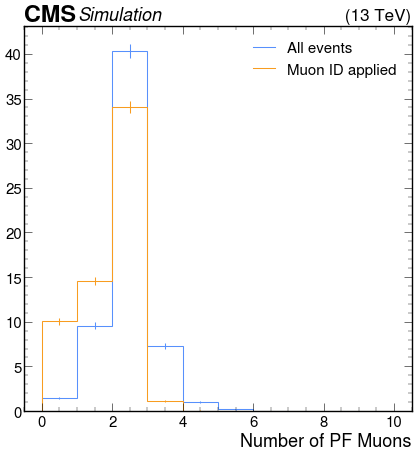

In [18]:
utilities.plot([
    out[samples[0]]["hists"]["muon_n"][channels[0], :],
    out[samples[0]]["hists"]["muon_n"][channels[1], :],
])
plt.legend(["All events", "Muon ID applied"])

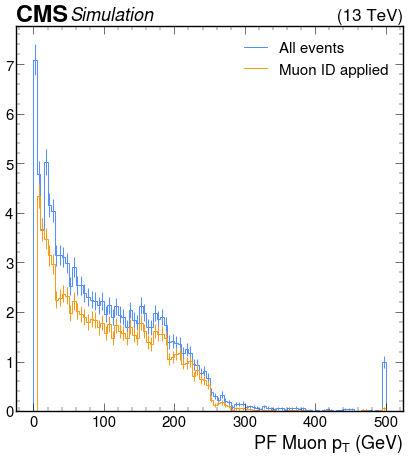

In [19]:
utilities.plot([
    out[samples[0]]["hists"]["muon_pt"][channels[0], :],
    out[samples[0]]["hists"]["muon_pt"][channels[1], :],
    #out[samples[0]]["hists"]["dsaMuon_numMatchedMuons"][channels[0], :]

])
plt.legend(["All events", "Muon ID applied"])

This is the important plot (below)... if we plot the pt of the matched muons, do we see the effect of applying the muon ID?

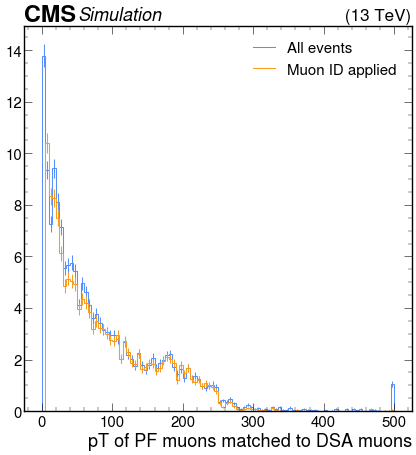

In [20]:
utilities.plot([
    out[samples[0]]["hists"]["dsaMuon_ptMatchedMuons"][channels[0], :],
    out[samples[0]]["hists"]["dsaMuon_ptMatchedMuons"][channels[1], :], 
])
plt.xlabel("pT of PF muons matched to DSA muons" )
plt.legend(["All events", "Muon ID applied"])

Yes! We can see the effect of the ID cuts on the orange curve (in particular the pt > 5 GeV cut)


Side note: I was also curious if this worked out of the box for other matched_x collections that are created via the schema. FWIW, I don't think we use any of those collections ourselves, so I created a new histogram to study it. 

Testing with electrons.matched_photons...

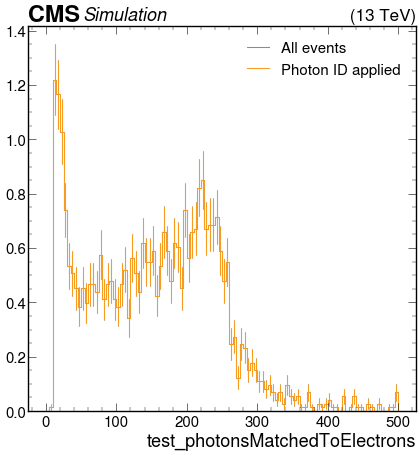

In [21]:
histname = "test_photonsMatchedToElectrons"
utilities.plot([
    out[samples[0]]["hists"][histname][channels[0], :],
    out[samples[0]]["hists"][histname][channels[1], :], 
])
plt.legend(["All events", "Photon ID applied"])

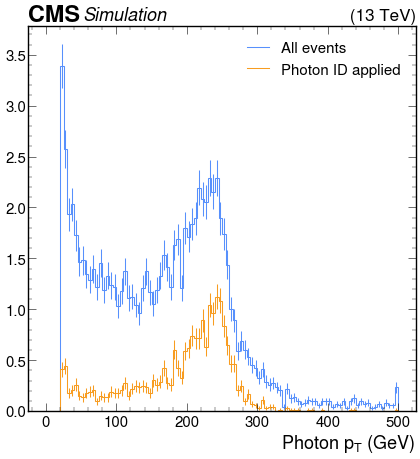

In [22]:
histname = "photon_pt"
utilities.plot([
    out[samples[0]]["hists"][histname][channels[0], :],
    out[samples[0]]["hists"][histname][channels[1], :], 
])
plt.legend(["All events", "Photon ID applied"])

Hmm, doesn't seem like it works for the normal matched_photon category either (plotting the matched pt looks more like the "all events" curve instead of the one with the photon ID applied)

Oh well. Finally, let's test the number of segment matches

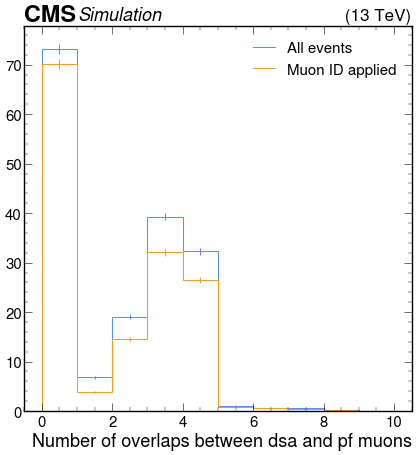

In [23]:
utilities.plot([
    out[samples[0]]["hists"]["dsaMuon_numOverlaps_MatchedMuons"][channels[0], :],
    out[samples[0]]["hists"]["dsaMuon_numOverlaps_MatchedMuons"][channels[1], :], 
])
plt.xlabel("Number of overlaps between dsa and pf muons" )
plt.legend(["All events", "Muon ID applied"])

I think this looks reasonable - yay!

# Junk

[2 3 2 ... 2 4 2]


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f3cf472bcb0>, errorbar=None, legend_artist=None)]

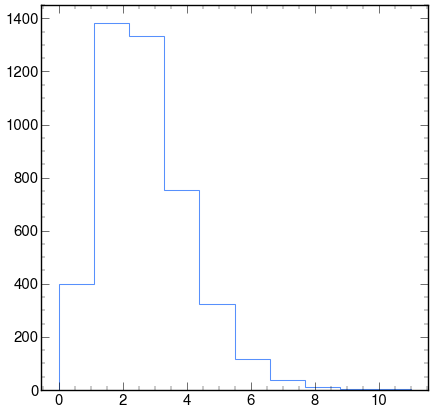

In [24]:
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np
muon_counts = ak.num(dsa.matched_muons.pt)
print(ak.to_numpy(muon_counts))
hep.histplot(np.histogram(ak.to_numpy(muon_counts)))

In [25]:
matched_pt = dsa.matched_muons.pt

print(matched_pt[0:2,:].to_list())
#Axis = 2 gives the number of pf muons that each dsa muon is matched to (5 by definition, counting None). Should still be double nested.)
print(ak.num(matched_pt, axis=2)) 
#Axis = 1 gives the number of dsa muons in the event. Should still be nested
print(ak.num(matched_pt, axis=1))
#Axis = 0 gives the number of events
print(ak.num(matched_pt, axis=0))

print()

flat = ak.flatten(matched_pt) #Gets rid of the event-level nesting
print(flat[0:2].to_list())
print(ak.num(flat))

print()

dropped_nones = ak.drop_none(matched_pt)
print(dropped_nones)
print(ak.num(dropped_nones,axis=2))
flat2 = ak.flatten(dropped_nones)
print(flat2[0:2].to_list())
print(ak.num(flat2))  #So we can either flatten then ak.num or use ak.num(axis=2) with 

print()

print(matched_pt[:,:1,:])

[[[135.23300170898438, 717.1842651367188, None, None, None], [717.1842651367188, 135.23300170898438, None, None, None]], [[5.346219539642334, 212.15811157226562, None, None, None], [212.15811157226562, 5.346219539642334, None, None, None], [5.346219539642334, 212.15811157226562, None, None, None]]]
[[5, 5], [5, 5, 5], [5, 5], [5, 5], ..., [5, ...], [5, 5], [5, 5, 5, 5], [5, 5]]
[2, 3, 2, 2, 5, 3, 1, 2, 2, 3, 3, 1, 3, ..., 3, 3, 4, 3, 3, 2, 5, 3, 3, 2, 4, 2]
4364

[[135.23300170898438, 717.1842651367188, None, None, None], [717.1842651367188, 135.23300170898438, None, None, None]]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ..., 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]

[[[135, 717], [717, 135]], [[5.35, ...], ...], ..., [[118, 142], [118, 142]]]
[[2, 2], [2, 2, 2], [2, 2], [2, 2], ..., [2, ...], [2, 2], [2, 2, 2, 2], [2, 2]]
[[135.23300170898438, 717.1842651367188], [717.1842651367188, 135.23300170898438]]
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ..., 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]

[[[135,

In [26]:
jet.fields

['area',
 'btagCSVV2',
 'btagDeepB',
 'btagDeepCvB',
 'btagDeepCvL',
 'btagDeepFlavB',
 'btagDeepFlavCvB',
 'btagDeepFlavCvL',
 'btagDeepFlavQG',
 'chEmEF',
 'chFPV0EF',
 'chHEF',
 'eta',
 'hfsigmaEtaEta',
 'hfsigmaPhiPhi',
 'mass',
 'muEF',
 'muonSubtrFactor',
 'neEmEF',
 'neHEF',
 'phi',
 'pt',
 'puIdDisc',
 'qgl',
 'rawFactor',
 'bRegCorr',
 'bRegRes',
 'cRegCorr',
 'cRegRes',
 'electronIdx1',
 'electronIdx2',
 'hfadjacentEtaStripsSize',
 'hfcentralEtaStripSize',
 'jetId',
 'muonIdx1',
 'muonIdx2',
 'nElectrons',
 'nMuons',
 'puId',
 'nConstituents',
 'genJetIdx',
 'hadronFlavour',
 'partonFlavour',
 'cleanmask',
 'electronIdx1G',
 'electronIdx2G',
 'genJetIdxG',
 'muonIdx1G',
 'muonIdx2G',
 'muonIdxG',
 'electronIdxG']

In [27]:
jet.matched_muons?

Type:            _DaskProperty
String form:     <dask_awkward.lib.core._DaskProperty object at 0x7f3cf6c6c4d0>
File:            /usr/local/lib/python3.12/site-packages/dask_awkward/lib/core.py
Docstring:      
The matched muons as determined by the NanoAOD branch muonIdx. The resulting awkward
array has two entries per jet, where if there are fewer than 2 muons matched to a jet, the
innermost dimensions are padded with None to be of size 2.
Class docstring:
A property descriptor that exposes a `.dask` method for registering
dask-awkward descriptor implementations.

In [28]:
dir(jet)

['E',
 'E2',
 'Et',
 'Et2',
 'LOOSE',
 'M',
 'M2',
 'Mask',
 'MomentumClass',
 'Mt',
 'Mt2',
 'ProjectionClass2D',
 'ProjectionClass3D',
 'ProjectionClass4D',
 'TIGHT',
 'TIGHTLEPVETO',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__get__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__self__',
 '__self_class__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__thisclass__',
 '_attrs',
 '_behavior',
 '_cpp_type',
 '_layout',
 '_numbaview',
 'absolute',
 'add',
 'add_kind',
 'add_systematic',
 'area',
 'attrs',
 'azimuthal',
 'bRegCorr',
 'bRegRes',
 'behavior',
 'beta',
 'boost',
 'boostCM_of',
 'boostCM_of_beta3',
 'boostCM_of_p4',
 'boostX',
 'boostY',
 'boostZ',
 'boost_beta3',
 'boost_p4',
 'boostvec',
 'btagCSVV2',
 'btagDeepB',
 'btagDeepCvB',
 'btagDeepCvL',
 'btagDeepF

In [29]:
ak.materialize(dsa.muonMatch1idx)

<Array [[1, 0], [1, 0, 1], ..., [...], [1, 1]] type='4364 * var * float32[p...'>

In [30]:
ak.materialize(jet.muonIdx1)

<Array [[-1, 1, -1, -1], ..., [-1, ..., -1]] type='4364 * var * int32[param...'>

In [31]:
ak.materialize(jet.matched_muons.pt)

<Array [[[None, None], ..., [None, ...]], ...] type='4364 * var * var * ?fl...'>

In [32]:
electron= events_llp.Electron
ak.materialize(electron.matched_jet.pt)

<Array [[286, 286], [None], ..., [198], [153]] type='4364 * var * ?float32[...'>

In [33]:
electron.fields

['dEscaleDown',
 'dEscaleUp',
 'dEsigmaDown',
 'dEsigmaUp',
 'deltaEtaSC',
 'dr03EcalRecHitSumEt',
 'dr03HcalDepth1TowerSumEt',
 'dr03TkSumPt',
 'dr03TkSumPtHEEP',
 'dxy',
 'dxyErr',
 'dz',
 'dzErr',
 'eCorr',
 'eInvMinusPInv',
 'energyErr',
 'eta',
 'hoe',
 'ip3d',
 'jetPtRelv2',
 'jetRelIso',
 'mass',
 'miniPFRelIso_all',
 'miniPFRelIso_chg',
 'mvaFall17V2Iso',
 'mvaFall17V2noIso',
 'pfRelIso03_all',
 'pfRelIso03_chg',
 'phi',
 'pt',
 'r9',
 'scEtOverPt',
 'sieie',
 'sip3d',
 'mvaTTH',
 'charge',
 'cutBased',
 'jetIdx',
 'pdgId',
 'photonIdx',
 'tightCharge',
 'vidNestedWPBitmap',
 'vidNestedWPBitmapHEEP',
 'convVeto',
 'cutBased_HEEP',
 'isPFcand',
 'jetNDauCharged',
 'lostHits',
 'mvaFall17V2Iso_WP80',
 'mvaFall17V2Iso_WP90',
 'mvaFall17V2Iso_WPL',
 'mvaFall17V2noIso_WP80',
 'mvaFall17V2noIso_WP90',
 'mvaFall17V2noIso_WPL',
 'seedGain',
 'genPartIdx',
 'genPartFlav',
 'cleanmask',
 'genPartIdxG',
 'jetIdxG',
 'photonIdxG']

In [34]:
jet.fields

['area',
 'btagCSVV2',
 'btagDeepB',
 'btagDeepCvB',
 'btagDeepCvL',
 'btagDeepFlavB',
 'btagDeepFlavCvB',
 'btagDeepFlavCvL',
 'btagDeepFlavQG',
 'chEmEF',
 'chFPV0EF',
 'chHEF',
 'eta',
 'hfsigmaEtaEta',
 'hfsigmaPhiPhi',
 'mass',
 'muEF',
 'muonSubtrFactor',
 'neEmEF',
 'neHEF',
 'phi',
 'pt',
 'puIdDisc',
 'qgl',
 'rawFactor',
 'bRegCorr',
 'bRegRes',
 'cRegCorr',
 'cRegRes',
 'electronIdx1',
 'electronIdx2',
 'hfadjacentEtaStripsSize',
 'hfcentralEtaStripSize',
 'jetId',
 'muonIdx1',
 'muonIdx2',
 'nElectrons',
 'nMuons',
 'puId',
 'nConstituents',
 'genJetIdx',
 'hadronFlavour',
 'partonFlavour',
 'cleanmask',
 'electronIdx1G',
 'electronIdx2G',
 'genJetIdxG',
 'muonIdx1G',
 'muonIdx2G',
 'muonIdxG',
 'electronIdxG']

In [35]:
jet.muonIdx1

<Array [[-1, 1, -1, -1], ..., [-1, ..., -1]] type='4364 * var * int32[param...'>

In [36]:
import awkward as ak
import numpy as np

def data_generator_with_typename():
    print("Generating data with custom typename...")
    # Create the actual content with the desired typename
    content = ak.Array([[1, 2], [], [3, 4, 5]], dtype="int32")
    return ak.with_parameter(content, "typename", "MyActualIntContent")

# Create a VirtualArray with this generator
virtual_arr_content_typename = ak.Array(data_generator_with_typename)

print(f"VirtualArray type (before materialization): {virtual_arr_content_typename.type}")

# Materialize the array
materialized_arr_content_typename = virtual_arr_content_typename
print(f"Materialized array type: {materialized_arr_content_typename.type}")

TypeError: Encountered unknown type function, and `allow_unknown` is `False`

In [ ]:
def ensure_array(arraylike):
    if isinstance(arraylike, (ak.contents.Content, ak.Array)):
        return ak.to_numpy(arraylike)
    elif isinstance(arraylike, ak.index.Index):
        return arraylike.data
    else:
        return np.asarray(arraylike)



In [ ]:
import numpy as np
from coffea.nanoevents import transforms

nMuon = ak.num(pf)
print(nMuon)

stack = []

stack.append(nMuon)

test = dsa.muonMatch1idx
print(test)
# print(test.type)
# test2 = ak.values_astype(test,np.int32)
# print(test2.type)

target_offsets = transforms.counts2offsets(stack)

counts = nMuon
offsets = np.empty(len(counts) + 1, dtype=np.int64)
offsets[0] = 0
np.cumsum(counts, out=offsets[1:])

target_offsets = offsets

print(target_offsets)
index = test
index = index.mask[index >= 0] + target_offsets[:-1]
index = index.mask[index < target_offsets[1:]]
out = ensure_array(ak.flatten(ak.fill_none(index, -1), axis=None))
print(out)

In [ ]:
import awkward as ak

In [ ]:
ak.with_field?

In [ ]:
ak.__version__